<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/PrePy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PrePy

Data preparation example

## Cardinality and Constants

**Code Explanation**

```python
constant_features = [
    feat for feat in df.columns if len(df[feat].unique()) == 1
]
```

This Python code snippet uses a list comprehension to identify columns in a Pandas DataFrame (`df`) that contain only a single unique value. Here's a step-by-step breakdown:

1.  **`df.columns`**: This retrieves a list of all column names from the DataFrame `df`.
2.  **`for feat in df.columns`**: This iterates through each column name, assigning the current column name to the variable `feat`.
3.  **`df[feat].unique()`**: For each column (`feat`), this extracts an array of the unique values present in that column.
4.  **`len(df[feat].unique()) == 1`**: This calculates the number of unique values in the column and checks if it's equal to 1. If it is, it means all values in that column are the same.
5.  **`[feat ... ]`**: If the condition in step 4 is true, the column name (`feat`) is added to the `constant_features` list.

**In essence, this code identifies columns that are "constant" – they don't provide any variability or information because they have only one value.**

**Why Cardinality and Constants Are Important in Data Modeling**

Now, let's discuss why cardinality and constants are crucial considerations in data modeling:

**1. Constants**

* **Redundancy and Noise:** Constant features add no predictive power to a model. They introduce redundancy and can even be considered noise, potentially slowing down training and affecting model performance.
* **Wasted Resources:** Storing and processing constant features wastes computational resources (memory, processing time) without providing any benefit.
* **Model Interpretation:** Including constant features can complicate model interpretation, as they don't contribute to understanding the relationships between variables.
* **Data Cleaning:** Identifying and removing constant features is an essential step in data cleaning and preprocessing.

**2. Cardinality**

Cardinality refers to the number of unique values in a categorical feature. It's important for several reasons:

* **High Cardinality:**
    * Features with very high cardinality (e.g., unique IDs, zip codes) can lead to overfitting, as the model may memorize specific patterns related to individual values rather than learning generalizable relationships.
    * They can create a large number of dummy variables when one-hot encoded, increasing the dimensionality of the data and computational complexity.
    * They might not provide meaningful insights if the unique values are not inherently ordered or related to the target variable.
* **Low Cardinality:**
    * Features with low cardinality (e.g., gender, day of the week) are often more useful for modeling, as they represent distinct categories with potential relationships to the target variable.
    * They are easier to handle and interpret.
* **Memory and Performance:** High-cardinality categorical variables can consume significant memory and slow down processing, especially when working with large datasets.
* **Encoding Strategies:** The choice of encoding strategy (e.g., one-hot encoding, label encoding, target encoding) depends on the cardinality of the feature. High-cardinality features might require more sophisticated encoding techniques.
* **Feature Engineering:** Understanding cardinality helps in feature engineering. You can group or bin high-cardinality features to create lower-cardinality features that are more informative.

**In summary:**

* **Constants** should generally be removed to improve model efficiency and reduce noise.
* **Cardinality** needs to be carefully considered to avoid overfitting, manage computational resources, and choose appropriate encoding strategies.

By addressing these issues, you can build more robust, efficient, and interpretable data models.


In [ ]:
constant_features = [
    feat for feat in df.columns if len(df[feat].unique()) == 1
]


## Quasi Constants

**Code Explanation**

```python
quasi_consts = []
for val in df.columns.sort_values():
  if (len(df[val].unique()) < 3 and max(df[val].value_counts(normalize=True)) > thresh):
    quasi_consts.append(val)
```

This Python code snippet identifies columns in a Pandas DataFrame (`df`) that are "quasi-constant" – meaning they have very few unique values, and one of those values occurs with a high frequency. Here's a detailed explanation:

1.  **`quasi_consts = []`**: Initializes an empty list called `quasi_consts` to store the names of the identified quasi-constant columns.
2.  **`df.columns.sort_values()`**: Gets the column names of the DataFrame `df` and sorts them alphabetically. This sorting is often done for consistency but doesn't change the logic.
3.  **`for val in df.columns.sort_values()`**: Iterates through each sorted column name, assigning the current column name to the variable `val`.
4.  **`len(df[val].unique()) < 3`**: Checks if the number of unique values in the column `val` is less than 3. This means it's looking for columns with only 1 or 2 unique values.
5.  **`df[val].value_counts(normalize=True)`**: Calculates the relative frequency of each unique value in the column `val`. `normalize=True` ensures the counts are represented as proportions (probabilities).
6.  **`max(df[val].value_counts(normalize=True)) > thresh`**: Finds the maximum relative frequency (the proportion of the most frequent value) and checks if it's greater than a predefined threshold `thresh`.
7.  **`if (len(df[val].unique()) < 3 and max(df[val].value_counts(normalize=True)) > thresh)`**: Combines the conditions from steps 4 and 6. A column is considered quasi-constant if it has fewer than 3 unique values and the most frequent value exceeds the threshold.
8.  **`quasi_consts.append(val)`**: If both conditions are met, the column name `val` is appended to the `quasi_consts` list.

**In essence, this code identifies columns where one value dominates, even if there's a second (or third) infrequent value.**

**Why Quasi-Constants Are Important in Data Modeling**

Quasi-constant features, while not entirely constant, can still pose challenges in data modeling:

* **Low Information Content:** They provide very little variability and, therefore, limited information for the model to learn from. The model might overemphasize the dominant value, leading to biased predictions.
* **Potential for Overfitting:** If the infrequent values are noisy or outliers, the model might try to fit to them, leading to overfitting.
* **Skewed Distributions:** Quasi-constant features often result in highly skewed distributions, which can violate assumptions of some statistical models.
* **Feature Importance:** They might appear to be important simply because they're strongly correlated with the dominant outcome, but they might not represent a genuine causal relationship.
* **Computational Efficiency:** While not as severe as constant features, quasi-constants can still add unnecessary computational burden, especially in high-dimensional datasets.
* **Threshold Dependence:** The identification of quasi-constants depends on the chosen threshold (`thresh`). Selecting an appropriate threshold is critical and requires careful consideration of the data and modeling goals.

**Practical Considerations**

* Determining the appropriate `thresh` value is essential. A very high threshold might miss some quasi-constants, while a low threshold might remove features that provide useful information.
* The context of the data is crucial. A feature might be quasi-constant in one dataset but highly informative in another.
* When dropping quasi constant variables, you should take into account the effect that could have on the model.
* Sometimes, quasi-constant features can be transformed or binned to create more informative features.

**In summary:**

* Quasi-constants should be carefully evaluated because they can introduce bias and reduce model performance.
* The decision to remove or transform them depends on the specific dataset and modeling objectives.
* It is very important to test the model with and without these features.


In [ ]:
quasi_consts = []
for val in df.columns.sort_values():
  if (len(df[val].unique()) < 3 and max(df[val].value_counts(normalize=True)) > thresh):
    quasi_consts.append(val)

## Duplicate Rows

**Code Explanation**

```python
len(df[df.duplicated(keep=False)])
```

This Python code snippet, using the Pandas library, calculates the total number of duplicate rows within a DataFrame (`df`). Here's a step-by-step breakdown:

1.  **`df.duplicated(keep=False)`**:
    * This Pandas method identifies duplicate rows within the DataFrame `df`.
    * The `keep=False` argument is crucial. It marks *all* duplicate rows as `True`, including the first occurrence. By default, `keep='first'` would only mark subsequent duplicates as `True`.
    * The result is a boolean Series (like a list) where `True` indicates a duplicate row and `False` indicates a unique row.
2.  **`df[df.duplicated(keep=False)]`**:
    * This uses boolean indexing to select the rows from the DataFrame `df` where the corresponding value in the boolean Series from step 1 is `True`. In other words, it creates a new DataFrame containing only the duplicate rows.
3.  **`len(...)`**:
    * This calculates the number of rows in the DataFrame resulting from step 2. This effectively counts the total number of duplicate rows in the original DataFrame `df`.

**In essence, this code returns the total number of rows that are duplicates of at least one other row in the DataFrame.**

**Why Addressing Duplicate Rows Is Important in Data Modeling**

Duplicate rows can significantly impact data modeling and analysis in several ways:

* **Bias and Misleading Statistics:**
    * Duplicates can skew statistical measures, such as means, medians, and standard deviations.
    * They can lead to an overestimation of the frequency of certain patterns or outcomes, resulting in biased models.
* **Overfitting:**
    * If a model is trained on data with duplicate rows, it may overfit to those specific duplicates, leading to poor generalization on unseen data.
    * The model might learn spurious patterns that are specific to the duplicated data, rather than generalizable relationships.
* **Reduced Model Performance:**
    * Duplicates can inflate the apparent size of the dataset without adding any new information, potentially slowing down training and reducing model efficiency.
* **Data Integrity Issues:**
    * Duplicate rows often indicate underlying data quality problems, such as errors in data collection, processing, or merging.
    * Addressing duplicates helps ensure data integrity and consistency.
* **Waste of Resources:**
    * Duplicate rows consume unnecessary memory and processing power.
* **Incorrect Evaluation:**
    * If a test set contains duplicate rows, it may lead to an overestimation of the models performance.

**How to Handle Duplicate Rows**

* **Identify Duplicates:** Use the `df.duplicated()` method to identify duplicate rows.
* **Remove Duplicates:** Use the `df.drop_duplicates()` method to remove duplicate rows. You can choose to keep the first or last occurrence of each duplicate or remove all of them.
* **Investigate the Source:** If duplicates are frequent, investigate the source of the data to identify and resolve the underlying data quality issues.
* **Aggregate Data:** In some cases, instead of removing duplicates, it might be appropriate to aggregate the data, such as calculating the mean or sum of relevant columns for each unique row.

By addressing duplicate rows, you can improve the quality, reliability, and performance of your data models.


In [ ]:
len(df[df.duplicated(keep=False)])

## Duplicate Columns

**Code Explanation**

```python
duplicate_features = []
for i in range(0, len(df.columns)):
    orig = df.columns[i]

    for dupe in df.columns[i + 1:]:
        if df[orig].equals(df[dupe]):
            duplicate_features.append(dupe)
```

This Python code snippet, using Pandas, identifies and stores the names of duplicate columns within a DataFrame (`df`). Here's a step-by-step breakdown:

1.  **`duplicate_features = []`**: Initializes an empty list called `duplicate_features` to store the names of the duplicate columns.
2.  **`for i in range(0, len(df.columns))`**: This outer loop iterates through each column in the DataFrame, using the index `i`.
3.  **`orig = df.columns[i]`**: Stores the name of the current column (the "original" column) being compared.
4.  **`for dupe in df.columns[i + 1:]`**: This inner loop iterates through the remaining columns in the DataFrame, starting from the column after the current `orig` column. This prevents comparing a column with itself and avoids redundant comparisons.
5.  **`if df[orig].equals(df[dupe])`**: This is the core logic. It checks if the values in the `orig` column are exactly equal to the values in the `dupe` column. The `equals()` method ensures a precise comparison of the entire Series.
6.  **`duplicate_features.append(dupe)`**: If the columns are equal (i.e., duplicates), the name of the duplicate column (`dupe`) is appended to the `duplicate_features` list.

**In essence, this code finds columns that contain identical data and stores the name of the duplicate columns.**

**Why Addressing Duplicate Columns Is Important in Data Modeling**

Duplicate columns, like duplicate rows, can introduce problems in data modeling:

* **Redundancy and Inefficiency:**
    * Duplicate columns provide redundant information, wasting storage space and increasing computational cost.
    * They don't add any new information to the model.
* **Multicollinearity:**
    * In statistical modeling (especially linear regression), duplicate columns represent perfect multicollinearity. This can lead to unstable and unreliable model coefficients.
    * It can make it difficult to determine the individual impact of each feature on the target variable.
* **Model Complexity:**
    * Duplicate columns can unnecessarily increase the complexity of the model, making it harder to interpret and understand.
* **Potential for Errors:**
    * If one of the duplicate columns is modified or updated, it could lead to inconsistencies if the other duplicate column is not updated accordingly.
* **Feature Importance Misinterpretation:**
    * If feature importance is calculated, both duplicate columns could appear important, when only one represents the information.

**How to Handle Duplicate Columns**

* **Identify Duplicates:** Use the code provided or similar methods to identify duplicate columns.
* **Remove Duplicates:** Use the `df.drop()` method to remove the duplicate columns. You should choose which column to keep based on its relevance, completeness, or ease of interpretation.
* **Investigate the Source:** If duplicate columns are frequent, investigate the data source to determine why they exist and prevent their creation in the future.
* **Feature Engineering:** Sometimes, the duplicate columns can be used to create new, more informative features.

By addressing duplicate columns, you can improve the efficiency, stability, and interpretability of your data models.


In [ ]:
duplicate_features = []
for i in range(0, len(df.columns)):
  orig = df.columns[i]

  for dupe in df.columns[i + 1:]:
    if df[orig].equals(df[dupe]):
        duplicate_features.append(dupe)

## Category Encoding

**Code Explanation**

This code snippet performs categorical feature encoding on a Pandas DataFrame (`df`) using a combination of techniques based on the cardinality (number of unique values) of the categorical features.

1.  **Identifying Categorical Features:**

    ```python
    cat_features = []
    for feat in df.select_dtypes(include=['object', 'category']):
    ```

    * This part identifies columns in the DataFrame that have data types 'object' (strings) or 'category'. These are typically categorical features.

2.  **Binary Encoding (Cardinality < 3):**

    ```python
    if len(df[feat].value_counts()) < 3:
        df[feat] = df[feat].map({df[feat].value_counts().index[0]: 0, df[feat].value_counts().index[1]: 1})
        df[feat] = df[feat].astype(int)
    ```

    * If a categorical feature has only two unique values (binary), it's encoded using a simple mapping: the most frequent value is mapped to 0, and the second most frequent to 1.
    * The column is then cast to integer type.

3.  **Storing Medium Cardinality Features (2 < Cardinality < 6):**

    ```python
    elif 2 < len(df[feat].value_counts()) < 6:
        cat_features.append(feat)
    ```

    * If a categorical feature has 3 to 5 unique values, its name is added to the `cat_features` list. These features will later be one-hot encoded.

4.  **Frequency Encoding (Cardinality > 5):**

    ```python
    elif len(df[feat].value_counts()) > 5:
        freq = df.groupby(feat, observed=False).size()/len(df)
        df[feat] = df[feat].map(freq)
    ```

    * If a categorical feature has more than 5 unique values (high cardinality), it's frequency encoded.
    * `df.groupby(feat).size()/len(df)` calculates the frequency of each unique value in the column.
    * `df[feat].map(freq)` replaces each value in the column with its corresponding frequency.

5.  **One-Hot Encoding:**

    ```python
    ohe = OneHotEncoder(categories='auto', drop='first', sparse_output=False, handle_unknown='ignore')
    ohe_df = ohe.fit_transform(df[cat_features])
    ohe_df = pd.DataFrame(ohe_df, columns=ohe.get_feature_names_out(cat_features))
    df.index = df.index
    df = df.join(ohe_df)
    df.drop(cat_features, axis=1, inplace=True)
    ```

    * `OneHotEncoder` from scikit-learn is used to one-hot encode the features in `cat_features`.
    * `drop='first'` removes the first category of each feature to avoid multicollinearity.
    * `sparse_output=False` returns a dense numpy array instead of a sparse matrix.
    * `handle_unknown='ignore'` ignores unknown categories that may appear in the test set.
    * The encoded features are converted into a new DataFrame (`ohe_df`).
    * The new one hot encoded dataframe is joined to the original dataframe.
    * The original categorical columns are dropped.

**Why Categorical Encoding Is Important in Data Modeling**

* **Machine Learning Algorithms:** Most machine learning algorithms work with numerical data. Categorical features need to be converted into numerical representations before they can be used in these algorithms.
* **Preventing Misinterpretation:** Without encoding, the algorithm might interpret categorical values as having a numerical order or ranking, which is often incorrect.
* **Improving Model Performance:** Proper encoding can significantly improve model performance by providing meaningful numerical representations of categorical data.
* **Handling Different Cardinality:** Different encoding techniques are suitable for different cardinalities.
    * Binary encoding is efficient for features with two categories.
    * One-hot encoding is suitable for low-to-medium cardinality features.
    * Frequency encoding is appropriate for high-cardinality features.
* **Avoiding Multicollinearity:** Techniques like dropping the first category in one-hot encoding help prevent multicollinearity, which can negatively affect model stability.
* **Feature Engineering:** Categorical encoding is a crucial part of feature engineering, allowing you to transform raw categorical data into features that are more informative for the model.

In summary, categorical encoding is a fundamental step in data preprocessing for machine learning. It ensures that categorical data is represented in a way that algorithms can understand and use effectively, leading to better model performance and more accurate predictions.


In [ ]:
cat_features = []
for feat in df.select_dtypes(include=['object', 'category']):
  if len(df[feat].value_counts()) < 3:
    df[feat] = df[feat].map({df[feat].value_counts().index[0]: 0, df[feat].value_counts().index[1]: 1})
    df[feat] = df[feat].astype(int)
  elif 2 < len(df[feat].value_counts()) < 6:
    cat_features.append(feat)
  elif len(df[feat].value_counts()) > 5:
    freq = df.groupby(feat, observed=False).size()/len(df)
    df[feat] = df[feat].map(freq)

ohe = OneHotEncoder(categories='auto', drop='first', sparse_output=False, handle_unknown='ignore')
ohe_df = ohe.fit_transform(df[cat_features])
ohe_df = pd.DataFrame(ohe_df, columns=ohe.get_feature_names_out(cat_features))
df.index = df.index
df = df.join(ohe_df)
df.drop(cat_features, axis=1, inplace=True)

## Missing Values

**Code Explanation**

This code snippet addresses missing values in a Pandas DataFrame (`df`) using different strategies based on the feature's data type and skewness.

1.  **Identifying Categorical Features:**

    ```python
    df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
    dfx = df.copy()
    ```

    * `df_categorical_features` stores the names of columns with 'category' or 'object' data types (categorical features).
    * `dfx = df.copy()` creates a copy of the original DataFrame to avoid modifying it directly.

2.  **Iterating Through Columns with Missing Values:**

    ```python
    for feat in df.columns[df.isnull().sum() > 1]:
    ```

    * This loop iterates through columns that have more than one missing value. `df.isnull().sum() > 1` identifies such columns.

3.  **Handling Categorical Features:**

    ```python
    if feat in df_categorical_features:
        dfx[feat] = df[feat].fillna(df[feat].mode()[0])
    ```

    * If the current column (`feat`) is categorical, missing values are filled with the mode (most frequent value) of that column. `df[feat].mode()[0]` gets the mode.

4.  **Handling Numerical Features (Based on Skewness):**

    ```python
    else:
        if abs(df[feat].skew()) < .8:
            dfx[feat] = df[feat].fillna(round(df[feat].mean(), 2))
        else:
            dfx[feat] = df[feat].fillna(df[feat].median())
    ```

    * If the column is numerical, the handling depends on its skewness:
        * If the absolute skewness is less than 0.8 (relatively symmetric distribution), missing values are filled with the mean, rounded to two decimal places.
        * If the absolute skewness is 0.8 or greater (skewed distribution), missing values are filled with the median.

**Why Addressing Missing Values Is Important in Data Modeling**

Missing values are a common problem in real-world datasets and can significantly impact data modeling in several ways:

* **Algorithm Compatibility:** Many machine learning algorithms cannot handle missing values. Trying to train a model on data with missing values can lead to errors or unexpected behavior.
* **Bias and Distortion:** Missing values can introduce bias into the data if they are not randomly distributed. Filling missing values with inappropriate values can distort the underlying relationships between variables.
* **Reduced Model Performance:** Missing values can reduce the amount of information available to the model, leading to lower accuracy and poorer generalization.
* **Data Integrity Issues:** Missing values can indicate underlying data quality problems, such as errors in data collection, processing, or storage.
* **Statistical Analysis:** Missing values can complicate statistical analysis and make it difficult to draw valid conclusions from the data.
* **Increased Model Complexity:** Some methods of dealing with missing data, like creating dummy variables for missing values, can increase the dimensionality of the data, which can negatively impact model performance.

**Why the Specific Filling Methods**

* **Mode for Categorical Features:** The mode is a suitable fill value for categorical features because it represents the most common category.
* **Mean for Symmetrical Numerical Features:** The mean is a good choice for filling missing values in symmetrical distributions because it represents the central tendency of the data. Rounding the mean to two decimal places is a common practice to avoid introducing unnecessary precision.
* **Median for Skewed Numerical Features:** The median is more robust to outliers than the mean and is, therefore, a better choice for skewed distributions.

**In summary:**

* Addressing missing values is crucial for building accurate and reliable data models.
* The choice of filling method should depend on the data type and distribution of the features.
* It is very important to document how and why missing values were handled.


In [ ]:
df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
dfx = df.copy()
for feat in df.columns[df.isnull().sum() > 1]:
  if feat in df_categorical_features:
    dfx[feat] = df[feat].fillna(df[feat].mode()[0])
  else:
    if abs(df[feat].skew()) < .8:
      dfx[feat] = df[feat].fillna(round(df[feat].mean(), 2))
    else:
      dfx[feat] = df[feat].fillna(df[feat].median())

## Standardized Scaling

**Code Explanation**

```python
feat = str(df._get_numeric_data().idxmax(1)[0])
scaler = StandardScaler()
df[feat] = scaler.fit_transform(df[[feat]].values)
```

This code snippet performs standardized scaling on a single numerical column within a Pandas DataFrame (`df`). Here's a step-by-step explanation:

1.  **`feat = str(df._get_numeric_data().idxmax(1)[0])`**:
    * `df._get_numeric_data()` selects only the numerical columns from the DataFrame.
    * `.idxmax(1)` finds the index (column name) of the maximum value in each row. Since we are only interested in a single column, we will be getting the first column name.
    * `[0]` extracts the first column name from the result.
    * `str()` converts the column name to a string, ensuring it can be used for indexing.
    * In short, this line selects the name of the first numerical column in the dataframe.

2.  **`scaler = StandardScaler()`**:
    * Creates an instance of the `StandardScaler` from scikit-learn. This scaler will standardize features by removing the mean and scaling to unit variance.

3.  **`df[feat] = scaler.fit_transform(df[[feat]].values)`**:
    * `df[[feat]].values` selects the specified column (`feat`) as a DataFrame (to maintain dimensionality) and converts it to a NumPy array.
    * `scaler.fit_transform(...)` fits the scaler to the data (calculates the mean and standard deviation) and then transforms the data (standardizes it).
    * `df[feat] = ...` replaces the original column in the DataFrame with the standardized values.

**Why Standardized Scaling Is Important in Data Modeling**

Standardized scaling (also known as Z-score normalization) is crucial for several reasons:

* **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. Features with larger ranges can dominate those with smaller ranges, leading to biased or suboptimal model performance.
* **Gradient Descent Optimization:** Gradient descent-based algorithms (e.g., linear regression, logistic regression, neural networks) converge faster when features are on a similar scale.
* **Distance-Based Algorithms:** Distance-based algorithms (e.g., k-nearest neighbors, k-means clustering) are highly sensitive to feature scales. Standardizing features ensures that distances are calculated fairly.
* **Regularization:** Regularization techniques (e.g., L1, L2 regularization) can be affected by feature scales. Standardizing features helps ensure that regularization is applied consistently.
* **Improving Model Stability:** Standardizing features can improve the numerical stability of some algorithms.

**When to Use Standardized Scaling**

Standardized scaling is generally recommended in these situations:

* **Algorithms Sensitive to Scale:** When using algorithms like:
    * Linear regression
    * Logistic regression
    * Support vector machines (SVMs)
    * Neural networks
    * K-nearest neighbors (KNN)
    * Principal component analysis (PCA)
* **Features with Gaussian-Like Distributions:** Standardized scaling works best when features have a roughly Gaussian (normal) distribution.
* **When Feature Ranges Vary Significantly:** If features have vastly different ranges (e.g., one feature ranges from 0 to 1, and another ranges from -1000 to 1000), standardized scaling is essential.
* **When Outliers Are Not a Major Concern:** Standardized scaling is sensitive to outliers. If your data contains significant outliers, robust scaling methods (e.g., `RobustScaler`) might be more appropriate.

**Key Points About Standardized Scaling**

* Transforms data to have a mean of 0 and a standard deviation of 1.
* Can be affected by outliers.
* Preserves the shape of the original distribution.
* Is a common and effective scaling technique for many machine learning algorithms.


In [ ]:
feat = str(df._get_numeric_data().idxmax(1)[0])
scaler = StandardScaler()
df[feat] = scaler.fit_transform(df[[feat]].values)

## MinMax Scaling

**Code Explanation**

```python
feat = str(df._get_numeric_data().idxmax(1)[0])
scaler = MinMaxScaler()
df[feat] = scaler.fit_transform(df[[feat]].values)
```

This code snippet performs min-max scaling on a single numerical column within a Pandas DataFrame (`df`). Here's a step-by-step explanation:

1.  **`feat = str(df._get_numeric_data().idxmax(1)[0])`**:
    * This line, as explained before, selects the first numerical column of the dataframe, and stores it as a string.
2.  **`scaler = MinMaxScaler()`**:
    * Creates an instance of the `MinMaxScaler` from scikit-learn. This scaler will transform features by scaling each feature to a given range, typically between 0 and 1.
3.  **`df[feat] = scaler.fit_transform(df[[feat]].values)`**:
    * `df[[feat]].values` selects the specified column (`feat`) as a DataFrame (to maintain dimensionality) and converts it to a NumPy array.
    * `scaler.fit_transform(...)` fits the scaler to the data (calculates the minimum and maximum values) and then transforms the data (scales it to the specified range).
    * `df[feat] = ...` replaces the original column in the DataFrame with the scaled values.

**Why Min-Max Scaling Is Important in Data Modeling**

Min-max scaling is essential for several reasons:

* **Range Normalization:** It ensures that all features are within a specific range, typically 0 to 1, which can be crucial for algorithms that are sensitive to feature ranges.
* **Preventing Feature Domination:** It prevents features with larger ranges from dominating those with smaller ranges, leading to fairer and more accurate model performance.
* **Image Processing:** Min-max scaling is commonly used in image processing to normalize pixel values to a specific range (e.g., 0 to 1 or 0 to 255).
* **Neural Networks:** Some neural network activation functions (e.g., sigmoid) work best with input values in a specific range.
* **Distance-Based Algorithms:** While standardized scaling is often preferred, min-max scaling can also be used with distance-based algorithms (e.g., k-nearest neighbors) to ensure that distances are calculated fairly.

**When to Use Min-Max Scaling**

Min-max scaling is generally recommended in these situations:

* **Algorithms Sensitive to Range:** When using algorithms that are sensitive to the range of input features, such as:
    * Neural networks (especially with certain activation functions)
    * Image processing algorithms
* **When You Need Data in a Specific Range:** If you need to transform your data to a specific range (e.g., 0 to 1), min-max scaling is the appropriate choice.
* **When You Know the Exact Minimum and Maximum Values:** If you know the exact minimum and maximum values of your data, min-max scaling can be more efficient than standardized scaling.
* **When Outliers Are Not a Major Concern:** Similar to standardized scaling, min-max scaling is sensitive to outliers. Outliers can significantly affect the minimum and maximum values, leading to skewed scaling.
* **When distributions are not Gaussian:** Min max scaling does not change the distribution of the data, and is therefore useful when the data is not normally distributed.

**Key Points About Min-Max Scaling**

* Transforms data to a specific range (typically 0 to 1).
* Sensitive to outliers.
* Preserves the shape of the original distribution.
* Is useful when a fixed range is required.


In [ ]:
feat = str(df._get_numeric_data().idxmax(1)[0])
scaler = MinMaxScaler()
df[feat] = scaler.fit_transform(df[[feat]].values)

It's important to clarify the terminology, as "normalization" can sometimes be a bit ambiguous. Here's a breakdown:

* **Min-max scaling:**
    * This technique transforms data to fit within a specific range, typically between 0 and 1.
    * It's done by subtracting the minimum value of the feature and then dividing by the range (maximum value minus minimum value).
    * Therefore it is a form of Normalization.
    * This is what is most commonly refered to as normalization.
* **Normalization (in a broader sense):**
    * "Normalization" can refer to a wider range of scaling techniques, including min-max scaling.
    * However, sometimes "normalization" can also be used to refer to techniques that change the shape of a distributions, such as making it closer to a normal distribution.
* **Standardization (Z-score normalization):**
    * This technique transforms data to have a mean of 0 and a standard deviation of 1.
    * It's done by subtracting the mean and then dividing by the standard deviation.
    * This is distinctly different from min-max scaling.

**In summary:**

* Min-max scaling is a specific type of normalization, where the goal is to rescale the data to a fixed range.
* Therefore, in many cases, min max scaling is refered to as normalization.
* It is very important to understand that standard scaling is a different process than min max scaling.

Therefore, while min-max scaling is a form of normalization, "normalization" itself can have broader meanings. It is very important to specify which form of normalization is being used, to prevent confusion.


## Outliers

**Code Explanation**

```python
feat = str(df._get_numeric_data().idxmax(1)[0])
scaler = RobustScaler()
df[feat] = scaler.fit_transform(df[[feat]].values)
```

This code snippet applies robust scaling to a selected numerical column within a Pandas DataFrame (`df`) using `RobustScaler` from scikit-learn.

1.  **`feat = str(df._get_numeric_data().idxmax(1)[0])`**:
    * This line, as previously discussed, selects the first numerical column in the dataframe, and stores its name as a string.

2.  **`scaler = RobustScaler()`**:
    * Creates an instance of the `RobustScaler`. This scaler is designed to handle outliers by using statistics that are less sensitive to extreme values.

3.  **`df[feat] = scaler.fit_transform(df[[feat]].values)`**:
    * `df[[feat]].values` selects the specified column (`feat`) as a DataFrame (to maintain dimensionality) and converts it to a NumPy array.
    * `scaler.fit_transform(...)` fits the scaler to the data (calculates the median and interquartile range) and then transforms the data (scales it using these robust statistics).
    * `df[feat] = ...` replaces the original column in the DataFrame with the robustly scaled values.

**Why Addressing Outliers Is Important in Data Modeling**

Outliers are data points that significantly deviate from the rest of the data. They can have a substantial impact on data modeling and analysis:

* **Distorted Statistics:**
    * Outliers can skew statistical measures like the mean and standard deviation, leading to inaccurate representations of the data.
* **Reduced Model Accuracy:**
    * Many machine learning algorithms are sensitive to outliers. Outliers can cause models to overfit to extreme values, leading to poor generalization on unseen data.
* **Biased Model Coefficients:**
    * In linear models, outliers can disproportionately influence the regression coefficients, leading to biased predictions.
* **Increased Error:**
    * Outliers can increase the overall error of a model, making it less reliable.
* **Violated Assumptions:**
    * Some statistical models rely on assumptions about the distribution of the data (e.g., normality). Outliers can violate these assumptions, making the model invalid.
* **Misleading Visualizations:**
    * Outliers can distort visualizations, making it difficult to identify meaningful patterns in the data.

**How to Address Outliers**

* **Detection:**
    * Use visualization techniques (e.g., box plots, scatter plots) to identify outliers.
    * Use statistical methods (e.g., Z-scores, IQR) to detect outliers.
* **Removal:**
    * Remove outliers if they are clearly errors or anomalies.
    * Be cautious when removing outliers, as they may contain valuable information.
* **Transformation:**
    * Use data transformation techniques (e.g., log transformation, power transformation) to reduce the impact of outliers.
    * Use scaling methods like RobustScaler.
* **Imputation:**
    * Replace outliers with more representative values (e.g., median, trimmed mean).
* **Robust Algorithms:**
    * Use machine learning algorithms that are less sensitive to outliers (e.g., robust regression, decision trees).

**When to Use RobustScaler**

* As the code demonstrates, `RobustScaler` is particularly useful when you want to scale your data without being heavily influenced by outliers.
* It is a good choice when you know that your data contains outliers and you want to maintain the relative order and spread of the majority of your data points.

In summary, addressing outliers is crucial for building robust and reliable data models. `RobustScaler` is a valuable tool for scaling data in the presence of outliers.


In [ ]:
feat = str(df._get_numeric_data().idxmax(1)[0])
scaler = RobustScaler()
df[feat] = scaler.fit_transform(df[[feat]].values)

`RobustScaler` from scikit-learn is a very good option for handling outliers. Let's discuss why and compare it to other methods.

**RobustScaler Explained**

* **How it works:**
    * `RobustScaler` scales features using statistics that are robust to outliers.
    * It removes the median and scales the data according to the quantile range (by default, the interquartile range or IQR).
    * The IQR is the range between the 1st quartile (25th percentile) and the 3rd quartile (75th percentile).
    * By using the median and IQR, `RobustScaler` is less affected by extreme values than `StandardScaler`, which uses the mean and standard deviation.

* **Why it's good for outliers:**
    * Outliers have a much smaller influence on the median and IQR than they do on the mean and standard deviation.
    * Therefore, `RobustScaler` provides more robust scaling when your data contains outliers.

**When to Use RobustScaler:**

* When your data contains outliers.
* When you want to reduce the impact of outliers on your scaling.
* When you want to maintain the relative order of your data points, even with outliers.

**Comparison with Other Methods**

1.  **StandardScaler:**
    * Very sensitive to outliers.
    * Not recommended when outliers are present.

2.  **MinMaxScaler:**
    * Also sensitive to outliers.
    * Outliers can significantly affect the minimum and maximum values, leading to skewed scaling.

3.  **QuantileTransformer:**
    * Can also handle outliers by transforming features to a uniform or normal distribution.
    * It does change the shape of the original distribution, which might not always be desired.
    * It can be very useful when you want to normalize the distribution of your features.

4.  **PowerTransformer:**
    * Applies power transforms (Yeo-Johnson or Box-Cox) to make the data more Gaussian-like.
    * Can also help with outliers, especially when the data is skewed.
    * Changes the shape of the original distribution.

**Recommendation**

* For most cases where you have outliers and you want to scale the data without significantly altering the distribution, `RobustScaler` is an excellent choice.
* If you also want to normalize the distribution of your features, `QuantileTransformer` or `PowerTransformer` could be considered.
* Always visualize your data before and after scaling to understand the effects of the transformation.

**In summary:**

* `RobustScaler` is a strong contender for handling outliers during scaling.
* It is very important to consider the affect that each scaling method has on your data, and what your specific goals are.


# Example

## PrePy

https://github.com/gitmystuff/preppy/tree/main

In [1]:
! git clone https://github.com/gitmystuff/preppy.git

Cloning into 'preppy'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 78 (delta 39), reused 27 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 26.56 KiB | 1.33 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [1]:
from preppy.version import __version__
print(__version__)

PrepPy Version: 0.1.0


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

def identify_consts(df):
  constant_features = [
      feat for feat in df.columns if len(df[feat].unique()) == 1
  ]
  return constant_features

def identify_quasi_consts(df, thresh=0.95):
  # quasi constant values
  quasi_consts = []
  for val in df.columns.sort_values():
      if (len(df[val].unique()) < 3 and max(df[val].value_counts(normalize=True)) > thresh):
          quasi_consts.append(val)

  return quasi_consts

def check_row_duplicates(df):
  # duplicate rows
  return len(df[df.duplicated(keep=False)])

def check_col_duplicates(df):
  # check of duplicate columns
  duplicate_features = []
  for i in range(0, len(df.columns)):
      orig = df.columns[i]

      for dupe in df.columns[i + 1:]:
          if df[orig].equals(df[dupe]):
              duplicate_features.append(dupe)

  return duplicate_features

def do_OHE(df):
  cat_features = []
  for feat in df.select_dtypes(include=['object', 'category']):
    if len(df[feat].value_counts()) < 3:
      df[feat] = df[feat].map({df[feat].value_counts().index[0]: 0, df[feat].value_counts().index[1]: 1})
      df[feat] = df[feat].astype(int)
    elif 2 < len(df[feat].value_counts()) < 6:
      cat_features.append(feat)
    elif len(df[feat].value_counts()) > 5:
      freq = df.groupby(feat, observed=False).size()/len(df)
      df[feat] = df[feat].map(freq)

  ohe = OneHotEncoder(categories='auto', drop='first', sparse_output=False, handle_unknown='ignore')
  ohe_df = ohe.fit_transform(df[cat_features])
  ohe_df = pd.DataFrame(ohe_df, columns=ohe.get_feature_names_out(cat_features))
  ohe_df.index = df.index
  df = df.join(ohe_df)
  df.drop(cat_features, axis=1, inplace=True)
  return df
  return df

def handle_missing_values(df):
  df_categorical_features = df.select_dtypes(include=['category', 'object']).columns
  dfx = df.copy()
  for feat in df.columns[df.isnull().sum() > 1]:
    if feat in df_categorical_features:
      dfx[feat] = df[feat].fillna(df[feat].mode()[0])
    else:
      if abs(df[feat].skew()) < .8:
        dfx[feat] = df[feat].fillna(round(df[feat].mean(), 2))
      else:
        dfx[feat] = df[feat].fillna(df[feat].median())

  return dfx

def handle_standard_scaler(df):
  feat = str(df._get_numeric_data().idxmax(1)[0])
  scaler = StandardScaler()
  df[feat] = scaler.fit_transform(df[[feat]].values)
  return df

def handle_minmax_scaler(df):
  feat = str(df._get_numeric_data().idxmax(1)[0])
  scaler = MinMaxScaler()
  df[feat] = scaler.fit_transform(df[[feat]].values)
  return df

def handle_outliers(df):
  feat = str(df._get_numeric_data().idxmax(1)[0])
  scaler = RobustScaler()
  df[feat] = scaler.fit_transform(df[[feat]].values)
  return df

## Create the Data

In [4]:
pip install Faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 15.2 MB/s eta 0:00:00


In [61]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_regression
from faker import Faker

fake = Faker()

output = []
for x in range(100):
    sex = np.random.choice(['egg', 'seed'], p=[0.5, 0.5])
    output.append({
        'categorical_1': sex,
        'categorical_2': np.random.choice(['A', 'B', 'C']),
        'name_1': fake.first_name_female() if sex == 'egg' else fake.first_name_male(),
        'name_2': fake.last_name(),
        'zip_code': fake.zipcode(),
        'date': fake.date_of_birth(),
        'location': fake.state_abbr()
    })

demographics = pd.DataFrame(output)

def make_null(r, w):
    if random.randint(0, 99) < w:
        return np.nan
    else:
        return r

# Generating features for linear regression with generic names
features, target = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)

generic_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
random.shuffle(generic_cols)
df = pd.DataFrame(data=features, columns=generic_cols)
df['target_variable'] = target

# Introduce non-linearities and interactions
df['feature_1_squared'] = df['feature_1']**2
df['interaction_1_2'] = df['feature_1'] * df['feature_2']

# Apply transformations and add noise
df['target_variable'] = df['target_variable'] + np.random.normal(0, 5, 100)
df['feature_4'] = df['feature_4'].apply(lambda x: abs(x) if x < 0 else x)

# Add missing values
for col in generic_cols:
    df[col] = df[col].apply(make_null, args=(10,))

df = pd.concat([df, demographics], axis=1)

print(df.shape)
print(df.info())
df.head()

(100, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   feature_4          88 non-null     float64
 1   feature_5          93 non-null     float64
 2   feature_1          92 non-null     float64
 3   feature_3          94 non-null     float64
 4   feature_2          94 non-null     float64
 5   target_variable    100 non-null    float64
 6   feature_1_squared  100 non-null    float64
 7   interaction_1_2    100 non-null    float64
 8   categorical_1      100 non-null    object 
 9   categorical_2      100 non-null    object 
 10  name_1             100 non-null    object 
 11  name_2             100 non-null    object 
 12  zip_code           100 non-null    object 
 13  date               100 non-null    object 
 14  location           100 non-null    object 
dtypes: float64(8), object(7)
memory usage: 11.8+ KB
None


,feature_4,feature_5,feature_1,feature_3,feature_2,target_variable,feature_1_squared,interaction_1_2,categorical_1,categorical_2,name_1,name_2,zip_code,date,location
0,0.975120,-0.677162,-0.012247,-0.897254,0.075805,-79.133856,0.000150,-0.000928,egg,C,Molly,Wilson,86600,1995-11-28,VT
1,0.081874,-0.485364,0.758969,-0.772825,-0.236819,-62.143517,0.576034,-0.179738,seed,B,Travis,Robinson,26438,1923-03-07,RI
2,1.412304,-0.908024,-0.562288,-1.012831,0.314247,-259.370046,0.316167,-0.176697,seed,A,Jason,Walker,60457,1958-08-04,TN
3,0.645120,0.361636,1.356240,-0.072010,1.003533,129.379154,1.839387,1.361031,seed,C,Daniel,Hawkins,10096,1975-09-30,PR
4,0.622700,0.280992,-1.952088,-0.151785,NaN,-123.611004,3.810647,-1.148447,seed,A,Ronald,Turner,24923,1958-04-07,DE


## PrepPy Functions

In [69]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import preppy.utils as preppy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(['target_variable'], axis=1)
y = df['target_variable']

X = preppy.functions.do_OHE(X)
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   feature_4          88 non-null     float64
 1   feature_5          93 non-null     float64
 2   feature_1          92 non-null     float64
 3   feature_3          94 non-null     float64
 4   feature_2          94 non-null     float64
 5   feature_1_squared  100 non-null    float64
 6   interaction_1_2    100 non-null    float64
 7   categorical_1      100 non-null    int64  
 8   name_1             100 non-null    float64
 9   name_2             100 non-null    float64
 10  zip_code           100 non-null    float64
 11  date               100 non-null    float64
 12  location           100 non-null    float64
 13  categorical_2_B    100 non-null    float64
 14  categorical_2_C    100 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 11.8 KB


## Pipelines

In [70]:
pipe = [
    # ('ohe', preppy.classes.PerformOHE()),
    ('constants', preppy.classes.RemoveConstants()),
    ('quasiconsts', preppy.classes.RemoveQuasiConstants()),
    ('scalar', StandardScaler()),
    ('missing', preppy.classes.HandleMissingValues())
]

pipe_X = Pipeline(pipe)
pipe_X.fit(X)


X = preppy.functions.handle_missing_values(X)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   feature_4          100 non-null    float64
 1   feature_5          100 non-null    float64
 2   feature_1          100 non-null    float64
 3   feature_3          100 non-null    float64
 4   feature_2          100 non-null    float64
 5   feature_1_squared  100 non-null    float64
 6   interaction_1_2    100 non-null    float64
 7   categorical_1      100 non-null    int64  
 8   name_1             100 non-null    float64
 9   name_2             100 non-null    float64
 10  location           100 non-null    float64
 11  categorical_2_B    100 non-null    float64
 12  categorical_2_C    100 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 10.3 KB


## Train Test Split Class

In [80]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split

class TrainTestSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, test_size=0.2, random_state=None, stratify=None):
        self.test_size = test_size
        self.random_state = random_state
        self.stratify = stratify
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def fit(self, X, y=None):
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=self.stratify
        )
        return self

    def transform(self, X, y=None):
        # The transform method is not really used in this case,
        # but we need to return something.
        return X

    def get_splits(self):
        return self.X_train, self.X_test, self.y_train, self.y_test

**1. `BaseEstimator`**

* **Purpose:**
    * `BaseEstimator` is a base class in scikit-learn that provides a standard interface for all estimators (including transformers and models).
    * It primarily ensures that your custom classes adhere to scikit-learn's conventions and can be used seamlessly within its ecosystem.
* **Key Features:**
    * **`get_params()`:** This method allows scikit-learn to retrieve the parameters of your estimator. It's crucial for functions like `GridSearchCV` and `Pipeline`, which need to inspect and manipulate the parameters.
    * **`set_params()`:** This method allows scikit-learn to set the parameters of your estimator. It's used by `GridSearchCV` and `Pipeline` to configure the estimator during the search or pipeline execution.
    * By inheriting from `BaseEstimator`, you gain these core functionalities without having to implement them yourself.
* **Why It's Important:**
    * Consistency: It enforces a consistent API, making your custom estimators compatible with scikit-learn's tools.
    * Integration: It enables your estimators to work smoothly with pipelines, cross-validation, and hyperparameter tuning.

**2. `TransformerMixin`**

* **Purpose:**
    * `TransformerMixin` is a mixin class specifically designed for transformers.
    * It provides a default implementation of the `fit_transform()` method.
* **Key Features:**
    * **`fit_transform(X, y=None, **fit_params)`:** This method combines the `fit()` and `transform()` steps into a single call.
        * The default implementation simply calls `self.fit(X, y, **fit_params)` followed by `self.transform(X)`.
        * You can override `fit_transform()` if you need a more efficient or customized implementation.
* **Why It's Important:**
    * Convenience: It saves you from having to write the `fit_transform()` method explicitly in every transformer.
    * Efficiency: While the default implementation works, you can optimize it for your specific transformer if needed.
    * By inheriting from TransformerMixin, you are stating that your class will be able to transform data.

**In summary:**

* When you create a custom estimator (like a transformer or a model), you should inherit from `BaseEstimator` to ensure it integrates well with scikit-learn.
* If your estimator is a transformer (i.e., it transforms data), you should also inherit from `TransformerMixin` to get the default `fit_transform()` implementation.

By using these mixin classes, you make your custom code more robust, maintainable, and compatible with the scikit-learn ecosystem.


In [ ]:
from sklearn.pipeline import Pipeline


# Create the pipeline
pipeline = Pipeline([
    ('splitter', TrainTestSplitter(test_size=0.3, random_state=42)),
])

# Fit the pipeline
pipeline.fit(X, y)

# Retrieve the splits if needed.
X_train, X_test, y_train, y_test = pipeline.named_steps['splitter'].get_splits()



In [91]:
print(f"X_train:\n{X_train.head()}\n")
print(f"X_test:\n{X_test.head()}\n")
print(f"y_train:\n{y_train.head()}\n")
print(f"y_test:\n{y_test.head()}\n")

X_train:
    feature_4  feature_5  feature_1  feature_3  feature_2  feature_1_squared  \
11   0.645248  -1.913280  -0.463418  -0.465730   0.241962           0.214756   
47   0.586857  -1.401851   0.791032  -0.909387   1.402794           0.625732   
85   0.514439   0.120296   0.622850  -1.067620  -0.142379           0.387942   
28   0.645248  -0.875618   0.538910  -1.037246  -0.190339           0.290424   
93   0.827231   0.322719  -1.002529  -0.018513  -0.288659           1.005065   

    interaction_1_2  categorical_1  name_1  name_2  location  categorical_2_B  \
11        -0.112130              0    0.01    0.01      0.02              0.0   
47         1.109655              1    0.01    0.01      0.05              0.0   
85        -0.088681              0    0.02    0.01      0.01              0.0   
28        -0.102575              1    0.01    0.01      0.05              0.0   
93         0.289389              1    0.01    0.02      0.03              1.0   

    categorical_2_C  
1

## Lasso Model

In [93]:
# X_train, X_test, y_train, y_test = train_test_split(X, y,
#                                                     test_size=0.20,
#                                                     random_state=42)

model = Lasso(alpha=10, fit_intercept=True)
# model = LinearRegression()
model.fit(X_train, y_train)

d = {'Feature': X_train.columns, 'Coef': model.coef_}
pipe_df = pd.DataFrame(d)
print(pipe_df)

              Feature       Coef
0           feature_4   9.631348
1           feature_5  78.797539
2           feature_1  34.711577
3           feature_3  54.597089
4           feature_2  29.257078
5   feature_1_squared  -0.000000
6     interaction_1_2  -0.000000
7       categorical_1  -0.000000
8              name_1   0.000000
9              name_2  -0.000000
10           location  -0.000000
11    categorical_2_B   0.000000
12    categorical_2_C  -0.000000


## Metrics

Model Training Score (R^2): 0.7043541284201322
Model Test Score (R^2): 0.7049771472733215
Model Predictions Score: 0.7049771472733215

MAE: 61.825414429684
MSE: 5521.209706350605
RMSE: 74.30484308812316

Prediction DataFrame:
        Actual   Predicted   Residuals
83  164.271434  159.740629    4.530805
53 -303.758973 -182.799527 -120.959445
70  109.042165   -7.036628  116.078793
45  183.159616  103.224592   79.935024
44  398.379440  287.542896  110.836544


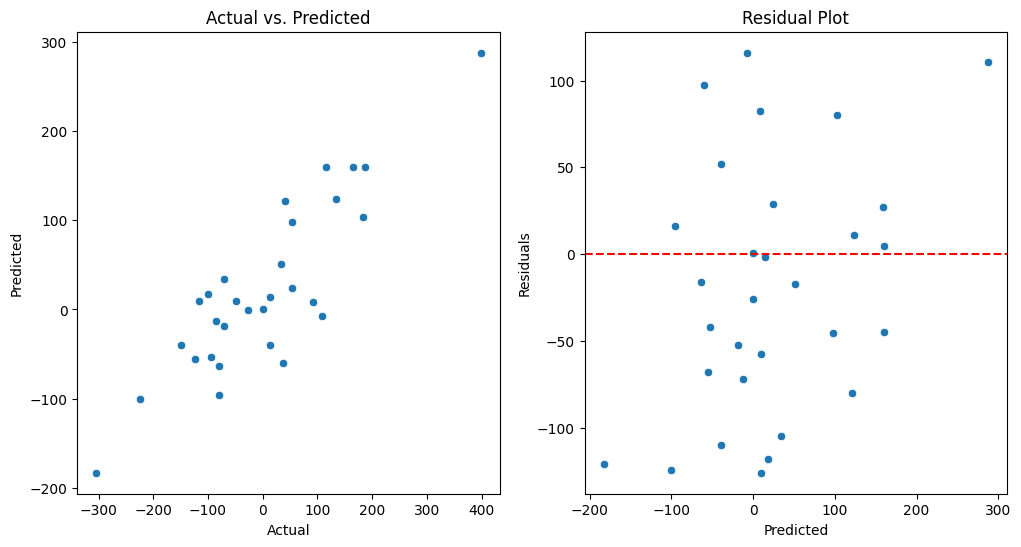

In [94]:
predictions = model.predict(X_test.dropna())

print(f'Model Training Score (R^2): {model.score(X_train, y_train)}')
print(f'Model Test Score (R^2): {model.score(X_test, y_test)}')
print(f'Model Predictions Score: {r2_score(y_test, predictions)}')

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print()
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')

# Prediction DataFrame
prediction_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions, 'Residuals': y_test - predictions})
print('\nPrediction DataFrame:')
print(prediction_df.head())

# Visualizations
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Actual', y='Predicted', data=prediction_df)
plt.title('Actual vs. Predicted')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Predicted', y='Residuals', data=prediction_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')

plt.show()

## OLS Model

In [95]:
import statsmodels.api as sm

X_train = X_train.copy()
X_train.insert(0, 'const', 1)
X_with_const = X_train

ols_model = sm.OLS(y_train, X_with_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        target_variable   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     14.37
Date:                Mon, 31 Mar 2025   Prob (F-statistic):           2.08e-13
Time:                        22:51:11   Log-Likelihood:                -394.26
No. Observations:                  70   AIC:                             816.5
Df Residuals:                      56   BIC:                             848.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -61.6676     44.77